# Curse of Dimensionality Assignment
## Mary Orrand  
## MLGEO 2026  

**Goal:**  
Create **one figure** that illustrates a key “curse of dimensionality” effect: as the number of dimensions (features) increases, **pairwise distances between random points become more similar** (they “concentrate”).

To show this, I will:
- simulate random points in different dimensions \(p\),
- compute many **pairwise Euclidean distances**,
- plot (A) **normalized** distance distributions for several \(p\) values, and
- plot (B) the **coefficient of variation** \(CV = \frac{\text{std}}{\text{mean}}\) across \(p\).

In [1]:
# Imports and configuration (first code cell)
from __future__ import annotations
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Reproducible RNG
RNG_SEED = 7
rng = np.random.default_rng(RNG_SEED)

# Figure output directory (created if it doesn't exist)
OUT_DIR = Path("figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RNG seed:", RNG_SEED)
print("Figures directory:", OUT_DIR.resolve())

RNG seed: 7
Figures directory: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\MLGEO-2026\data\assignments\CurseofDimensionality\CoD_Orrand\figures


## Step 1: Sample pairwise distances

To explore how distances behave as dimension increases, I first need a way to generate distances from simulated data.

I define a helper function:

`sample_pairwise_distances(rng, n_points, dim, n_pairs)`

This function:
- draws `n_points` random points from a **`dim`-dimensional standard normal** distribution,
- selects `n_pairs` random pairs of points (avoiding using the same point twice in a pair),
- returns the **Euclidean distance** for each pair.

After defining the function, I run a quick sanity check with modest values (e.g., `n_points=1000`, `n_pairs=5000`) and print the mean, standard deviation, and coefficient of variation (CV = std/mean).
If this works and runs quickly, I can move on to building the final plot.

In [2]:
# Distance sampling helper (second code cell)

def sample_pairwise_distances(
    rng: np.random.Generator,
    n_points: int,
    dim: int,
    n_pairs: int,
) -> np.ndarray:
    """
    Sample `n_points` from a `dim`-dimensional standard normal distribution and
    compute Euclidean distances for `n_pairs` random pairs of points.

    Returns
    -------
    np.ndarray
        Array of length `n_pairs` containing Euclidean distances.
    """
    x = rng.standard_normal(size=(n_points, dim))

    i = rng.integers(0, n_points, size=n_pairs)
    j = rng.integers(0, n_points, size=n_pairs)

    same = (i == j)
    if np.any(same):
        j[same] = (j[same] + 1) % n_points

    return np.linalg.norm(x[i] - x[j], axis=1)

In [3]:
# Sanity check (third code cell)

test_dim = 5
test_n_points = 1000
test_n_pairs = 5000

d = sample_pairwise_distances(
    rng=rng,
    n_points=test_n_points,
    dim=test_dim,
    n_pairs=test_n_pairs,
)

mean = d.mean()
std = d.std(ddof=1)
cv = std / mean

print(f"dim={test_dim}, n_points={test_n_points}, n_pairs={test_n_pairs}")
print(f"mean distance = {mean:.4f}")
print(f"std distance  = {std:.4f}")
print(f"CV (std/mean) = {cv:.4f}")
print(f"min/max       = {d.min():.4f} / {d.max():.4f}")

dim=5, n_points=1000, n_pairs=5000
mean distance = 3.0089
std distance  = 0.9515
CV (std/mean) = 0.3162
min/max       = 0.3551 / 6.6986


## Step 2: Build the final figure

Now that the distance-sampling function works, I will create the final figure required by the assignment.

The figure will have two panels:

**(A) Normalized distance distributions:**  
For a few dimensions (e.g., 2, 10, 50, 100), I plot histograms of many pairwise distances.  
To compare different dimensions fairly, I divide each distance by the mean distance for that dimension:
\[
\text{normalized distance}=\frac{\text{distance}}{\text{mean(distance)}}
\]
If distances “concentrate,” these histograms should become narrower and cluster near 1 as dimension increases.

**(B) Coefficient of variation (CV) vs dimension:**  
I compute \(CV=\frac{\text{std}}{\text{mean}}\) for each dimension.  
If distances become more similar in higher dimensions, CV should decrease as \(p\) increases.

Finally, I save the figure as a `.png` (and `.pdf`) in my `OUT_DIR` folder.

Saved PNG: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\MLGEO-2026\data\assignments\CurseofDimensionality\CoD_Orrand\figures\curse_of_dimensionality.png
Saved PDF: C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\MLGEO-2026\data\assignments\CurseofDimensionality\CoD_Orrand\figures\curse_of_dimensionality.pdf


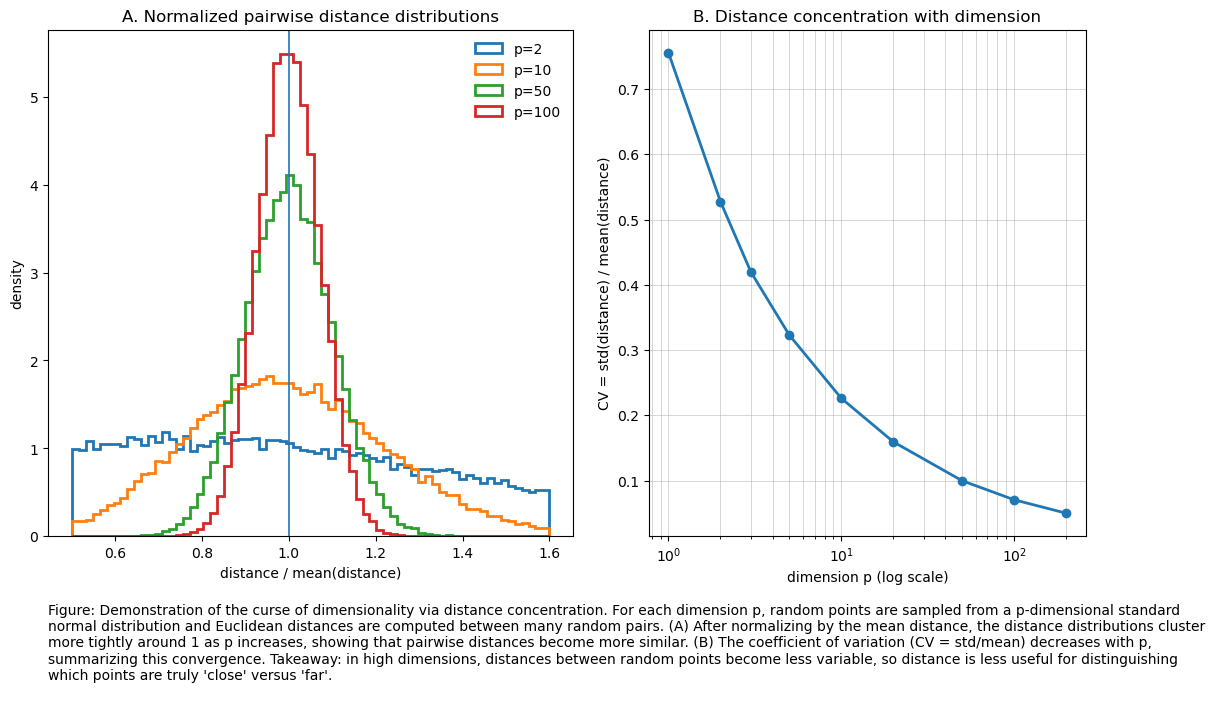

In [4]:
# Final figure: distance concentration with dimension (single figure)

# Simulation settings
N_POINTS = 6000
N_PAIRS = 50000

DIMS_HIST = [2, 10, 50, 100]
DIMS_TREND = [1, 2, 3, 5, 10, 20, 50, 100, 200]

# Panel A data: normalized distance distributions
dist_norm = {}
for p in DIMS_HIST:
    d = sample_pairwise_distances(rng, n_points=N_POINTS, dim=p, n_pairs=N_PAIRS)
    dist_norm[p] = d / d.mean()

# Panel B data: CV vs dimension
cvs = []
for p in DIMS_TREND:
    d = sample_pairwise_distances(rng, n_points=N_POINTS, dim=p, n_pairs=N_PAIRS)
    cvs.append(d.std(ddof=1) / d.mean())

# Figure layout: 2 plots + caption row (prevents tiny plots)
fig = plt.figure(figsize=(12, 7), constrained_layout=True)
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[14, 3], width_ratios=[1.2, 1.0])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax_cap = fig.add_subplot(gs[1, :])
ax_cap.axis("off")

# Panel A: histograms
bins = np.linspace(0.5, 1.6, 70)
for p in DIMS_HIST:
    ax1.hist(dist_norm[p], bins=bins, density=True, histtype="step", linewidth=2, label=f"p={p}")

ax1.set_title("A. Normalized pairwise distance distributions")
ax1.set_xlabel("distance / mean(distance)")
ax1.set_ylabel("density")
ax1.axvline(1.0, linewidth=1.2)
ax1.legend(frameon=False)

# Panel B: CV trend
ax2.plot(DIMS_TREND, cvs, marker="o", linewidth=2)
ax2.set_xscale("log")
ax2.set_title("B. Distance concentration with dimension")
ax2.set_xlabel("dimension p (log scale)")
ax2.set_ylabel("CV = std(distance) / mean(distance)")
ax2.grid(True, which="both", linewidth=0.6, alpha=0.6)

# Caption (assignment-style)
caption = (
    "Figure: Demonstration of the curse of dimensionality via distance concentration. "
    "For each dimension p, random points are sampled from a p-dimensional standard normal distribution and "
    "Euclidean distances are computed between many random pairs. "
    "(A) After normalizing by the mean distance, the distance distributions cluster more tightly around 1 as p increases, "
    "showing that pairwise distances become more similar. "
    "(B) The coefficient of variation (CV = std/mean) decreases with p, summarizing this convergence. "
    "Takeaway: in high dimensions, distances between random points become less variable, so distance is less useful for "
    "distinguishing which points are truly 'close' versus 'far'."
)
ax_cap.text(0.0, 0.9, caption, ha="left", va="top", fontsize=10, wrap=True)

# Save to your OUT_DIR
png_path = OUT_DIR / "curse_of_dimensionality.png"
pdf_path = OUT_DIR / "curse_of_dimensionality.pdf"

fig.savefig(png_path, dpi=300)
fig.savefig(pdf_path)

print("Saved PNG:", png_path.resolve())
print("Saved PDF:", pdf_path.resolve())

plt.show()